In [259]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sergionefedov/gym-will-your-new-years-resolution-survive/data_dictionary.csv
/kaggle/input/datasets/sergionefedov/gym-will-your-new-years-resolution-survive/gym_ghosts_master.csv


# **1. Importing Libraries**

In [260]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# import missingno as msno
import tensorflow as tf
from tensorflow import keras
data=pd.read_csv("/kaggle/input/datasets/sergionefedov/gym-will-your-new-years-resolution-survive/gym_ghosts_master.csv")
og=data.copy()
print('Data:')
data

Data:


,member_id,age,sex,distance_km,prior_gym_experience,joined_with_friend,contract_type,monthly_fee_usd,signup_week_january,promo_used,...,week3_visits,week4_visits,avg_weekly_classes,booked_induction,personal_trainer,app_installed,avg_session_minutes,guest_passes_used,locker_rented,churned_by_february
0,GYM000000,40,F,6.6,1,0,6_month,47.07,1,0,...,1,1,1,0,0,0,42,1,0,1
1,GYM000001,55,F,3.8,0,0,month_to_month,62.59,4,1,...,2,2,1,0,0,0,62,0,0,1
2,GYM000002,26,F,3.9,0,0,annual,36.68,2,1,...,2,0,0,1,0,0,17,1,1,1
3,GYM000003,20,M,0.4,0,0,annual,51.52,1,0,...,2,3,2,1,0,1,67,0,0,0
4,GYM000004,47,M,0.4,0,0,month_to_month,57.02,4,0,...,1,1,2,0,0,1,64,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,GYM049995,23,M,12.1,1,0,month_to_month,66.65,2,0,...,5,1,4,1,0,0,68,0,1,0
49996,GYM049996,37,M,6.1,0,0,month_to_month,66.93,2,0,...,1,0,2,0,0,1,50,2,1,0
49997,GYM049997,57,M,1.9,0,0,month_to_month,56.98,2,1,...,0,0,1,0,0,0,19,0,0,0
49998,GYM049998,31,Other,4.7,0,1,6_month,52.95,2,0,...,6,4,4,1,0,1,44,0,0,0


# **2.Reading Data**

In [261]:
print('\nShape:')
data.shape


Shape:


(50000, 24)

In [262]:
print('\nInfo:')
data.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   member_id             50000 non-null  object 
 1   age                   50000 non-null  int64  
 2   sex                   50000 non-null  object 
 3   distance_km           50000 non-null  float64
 4   prior_gym_experience  50000 non-null  int64  
 5   joined_with_friend    50000 non-null  int64  
 6   contract_type         50000 non-null  object 
 7   monthly_fee_usd       50000 non-null  float64
 8   signup_week_january   50000 non-null  int64  
 9   promo_used            50000 non-null  int64  
 10  primary_goal          50000 non-null  object 
 11  goal_aggressiveness   50000 non-null  int64  
 12  week1_visits          50000 non-null  int64  
 13  week2_visits          50000 non-null  int64  
 14  week3_visits          50000 non-null  int64  
 15  week4_visits

In [263]:
print('\nStatistics:')
data.describe()


Statistics:


,age,distance_km,prior_gym_experience,joined_with_friend,monthly_fee_usd,signup_week_january,promo_used,goal_aggressiveness,week1_visits,week2_visits,week3_visits,week4_visits,avg_weekly_classes,booked_induction,personal_trainer,app_installed,avg_session_minutes,guest_passes_used,locker_rented,churned_by_february
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000
mean,32.23222,6.020744,0.450320,0.280460,53.903658,1.992120,0.550560,2.99932,2.805320,2.38704,1.966880,1.63194,1.578540,0.451420,0.149380,0.60026,48.107020,0.483900,0.27352,0.451200
std,9.49437,4.275988,0.497531,0.449228,11.747882,1.037805,0.497442,1.41574,2.346446,2.08949,1.829822,1.60311,1.552598,0.497639,0.356466,0.48985,16.039848,0.710205,0.44577,0.497618
min,16.00000,0.100000,0.000000,0.000000,15.000000,1.000000,0.000000,1.00000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000,0.000000,0.00000,10.000000,0.000000,0.00000,0.000000
25%,25.00000,2.900000,0.000000,0.000000,45.700000,1.000000,0.000000,2.00000,1.000000,1.00000,1.000000,0.00000,0.000000,0.000000,0.000000,0.00000,37.000000,0.000000,0.00000,0.000000
50%,32.00000,5.000000,0.000000,0.000000,53.740000,2.000000,1.000000,3.00000,2.000000,2.00000,2.000000,1.00000,1.000000,0.000000,0.000000,1.00000,48.000000,0.000000,0.00000,0.000000
75%,39.00000,8.100000,1.000000,1.000000,61.830000,3.000000,1.000000,4.00000,4.000000,3.00000,3.000000,2.00000,2.000000,1.000000,0.000000,1.00000,59.000000,1.000000,1.00000,1.000000
max,71.00000,40.000000,1.000000,1.000000,101.890000,4.000000,1.000000,5.00000,14.000000,14.00000,14.000000,14.00000,12.000000,1.000000,1.000000,1.00000,115.000000,5.000000,1.00000,1.000000


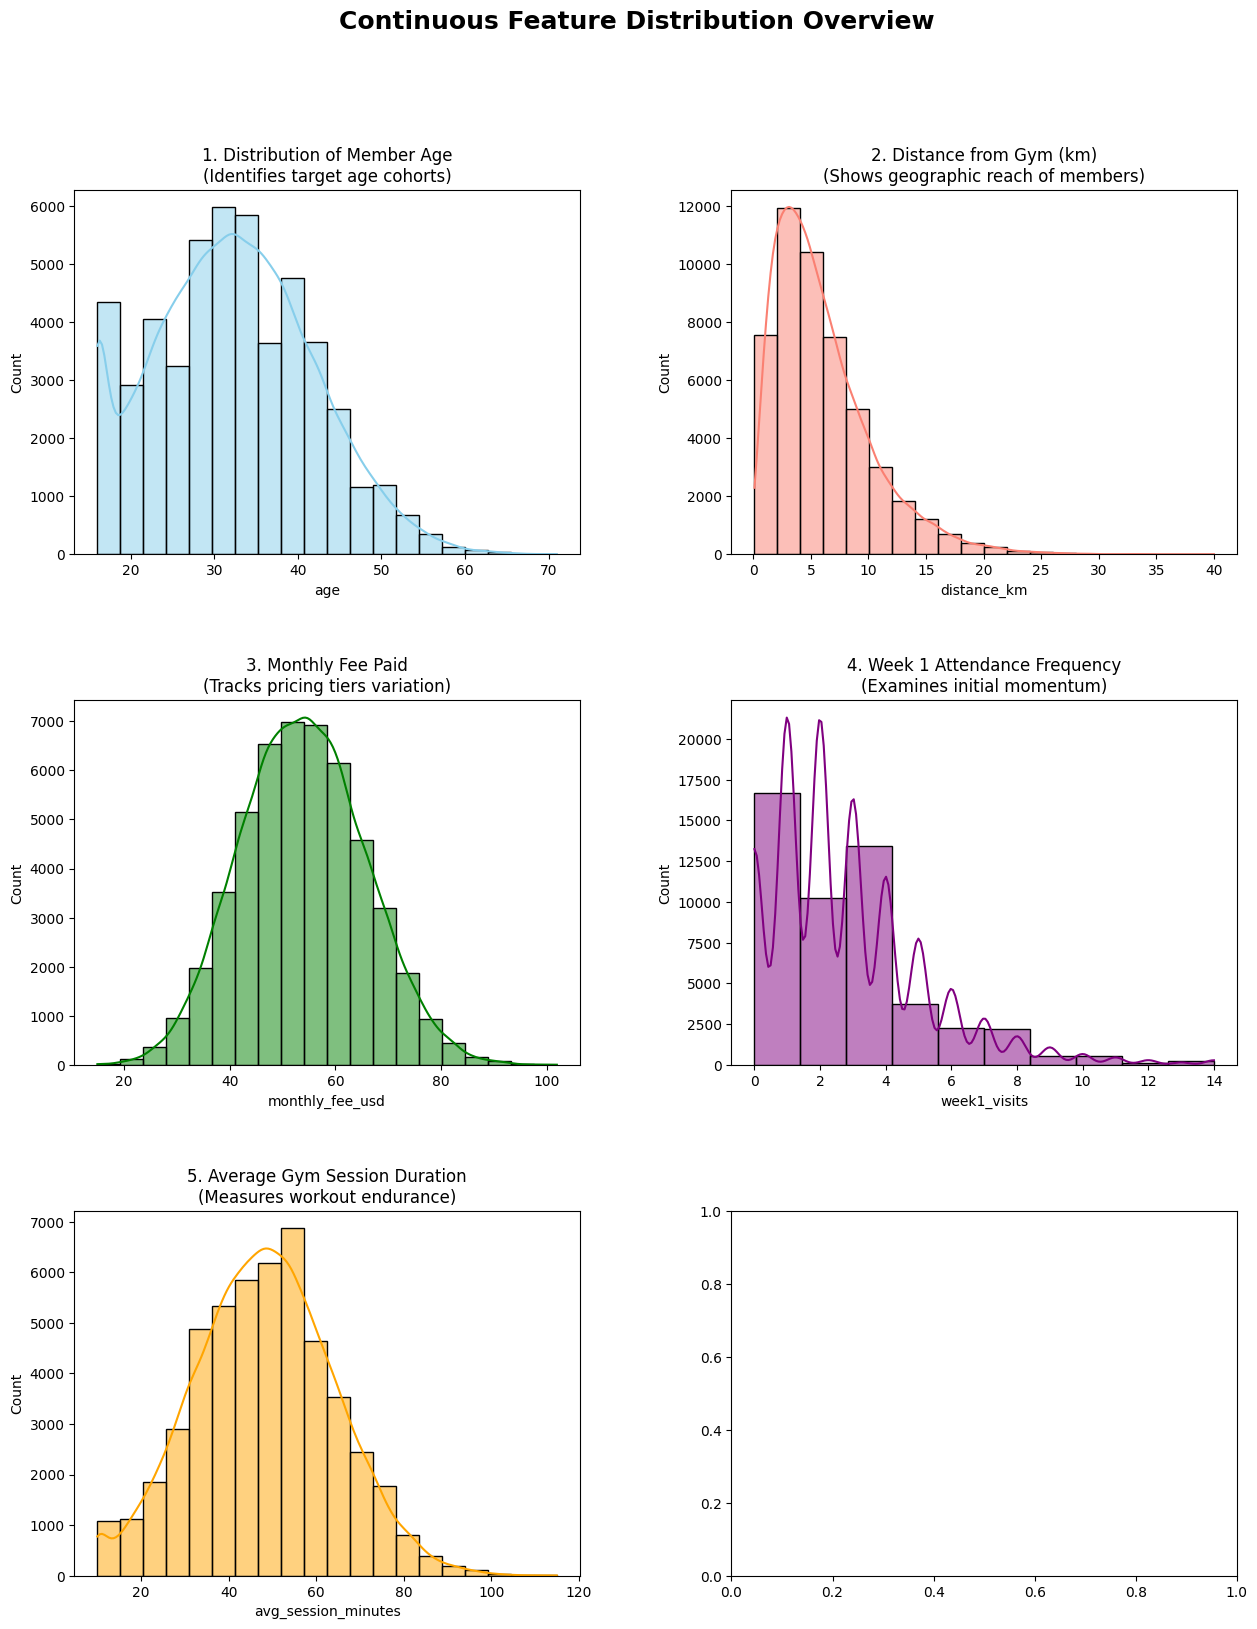

In [264]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Age Distribution
sns.histplot(data=data, x='age', kde=True, ax=axes[0,0], color='skyblue', bins=20)
axes[0,0].set_title('1. Distribution of Member Age\n(Identifies target age cohorts)')

# 2. Distance Distribution
sns.histplot(data=data, x='distance_km', kde=True, ax=axes[0,1], color='salmon', bins=20)
axes[0,1].set_title('2. Distance from Gym (km)\n(Shows geographic reach of members)')

# 3. Monthly Fee USD
sns.histplot(data=data, x='monthly_fee_usd', kde=True, ax=axes[1,0], color='green', bins=20)
axes[1,0].set_title('3. Monthly Fee Paid\n(Tracks pricing tiers variation)')

# 4. Week 1 Visits
sns.histplot(data=data, x='week1_visits', kde=True, ax=axes[1,1], color='purple', bins=10)
axes[1,1].set_title('4. Week 1 Attendance Frequency\n(Examines initial momentum)')

# 5. Average Session Minutes
sns.histplot(data=data, x='avg_session_minutes', kde=True, ax=axes[2,0], color='orange', bins=20)
axes[2,0].set_title('5. Average Gym Session Duration\n(Measures workout endurance)')

plt.suptitle("Continuous Feature Distribution Overview", fontsize=18, weight='bold')
plt.show()

In [265]:
# Capture attendance drop-off or improvement
data['visit_trend'] = data['week4_visits'] - data['week1_visits']
data['total_visits'] = data['week1_visits'] + data['week2_visits'] + data['week3_visits'] + data['week4_visits']
data['recent_activity_ratio'] = (data['week3_visits'] + data['week4_visits']) / (data['total_visits'] + 1e-5)

In [266]:
# High commitment indicators
data['engagement_score'] = data['booked_induction'] + data['personal_trainer'] + data['app_installed'] + data['locker_rented']

In [267]:
# Value per visit
data['cost_per_visit'] = data['monthly_fee_usd'] / (data['total_visits'] + 1)

/tmp/ipykernel_58/1339001170.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


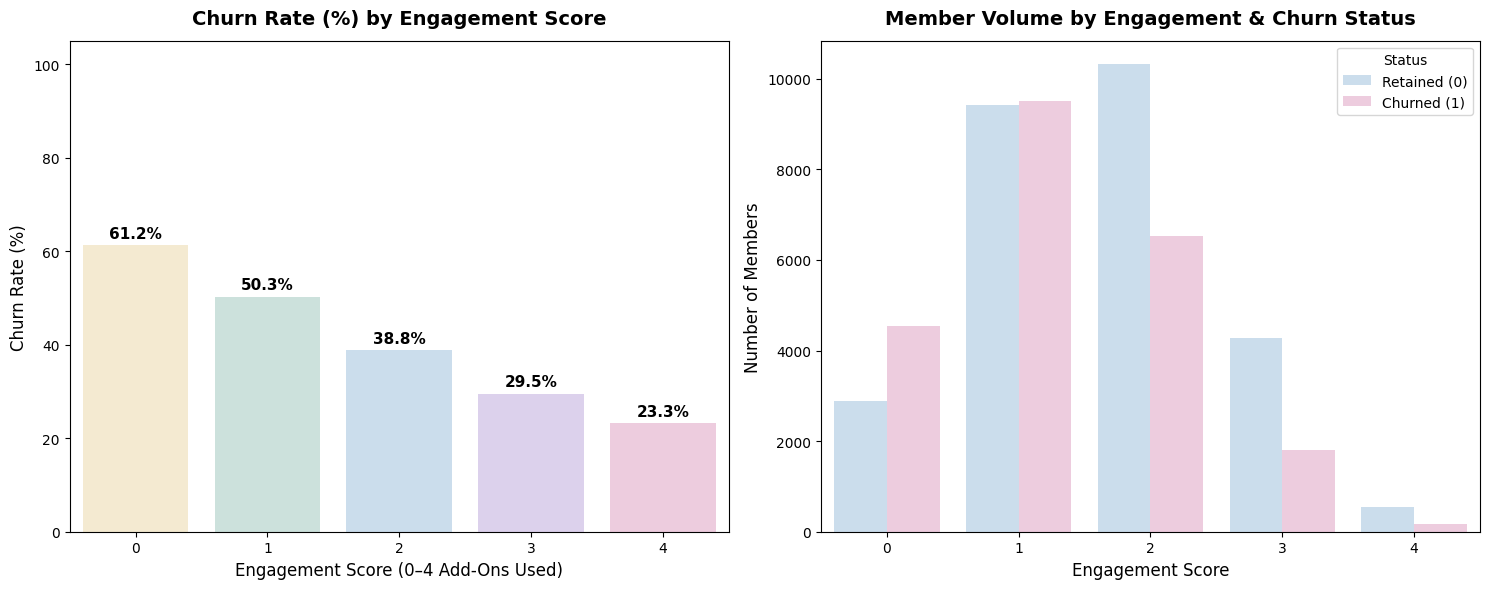

In [268]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 🎨 YOUR PASTEL HEX PALETTE
# ==========================================
my_hex_colors = [
    '#FAEDCB',  # 0 Add-Ons (Warm Cream)
    '#C9E4DE',  # 1 Add-On  (Soft Mint)
    '#C6DEF1',  # 2 Add-Ons (Light Blue)
    '#DBCDF0',  # 3 Add-Ons (Lavender)
    '#F2C6DE',  # 4 Add-Ons (Soft Pink)
    '#F7D9C4',  # Extra    (Peach)
]

retained_hex = '#C6DEF1'  # Soft Blue for Retained (0)
churned_hex = '#F2C6DE'   # Soft Pink for Churned (1)
# ==========================================

# 1. Calculate churn rate by engagement score
engagement_summary = (
    data.groupby('engagement_score')['churned_by_february']
    .agg(total_members='count', churn_rate='mean')
    .reset_index()
)

engagement_summary['churn_rate_pct'] = engagement_summary['churn_rate'] * 100

# 2. Set up side-by-side visual plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left Plot: Churn Rate Percentage ---
sns.barplot(
    data=engagement_summary, 
    x='engagement_score', 
    y='churn_rate_pct', 
    palette=my_hex_colors[:5],  # Uses the first 5 pastel colors for scores 0–4
    ax=axes[0]
)
axes[0].set_title('Churn Rate (%) by Engagement Score', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Engagement Score (0–4 Add-Ons Used)', fontsize=12)
axes[0].set_ylabel('Churn Rate (%)', fontsize=12)
axes[0].set_ylim(0, 105)

# Annotate bars with exact percentages
for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom', fontsize=11, fontweight='bold', xytext=(0, 3),
        textcoords='offset points'
    )

# --- Right Plot: Retained vs. Churned Counts ---
sns.countplot(
    data=data, 
    x='engagement_score', 
    hue='churned_by_february', 
    palette=[retained_hex, churned_hex],  # Blue = Retained, Pink = Churned
    ax=axes[1]
)
axes[1].set_title('Member Volume by Engagement & Churn Status', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Engagement Score', fontsize=12)
axes[1].set_ylabel('Number of Members', fontsize=12)
axes[1].legend(title='Status', labels=['Retained (0)', 'Churned (1)'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_58/3440346170.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_58/3440346170.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_58/3440346170.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])


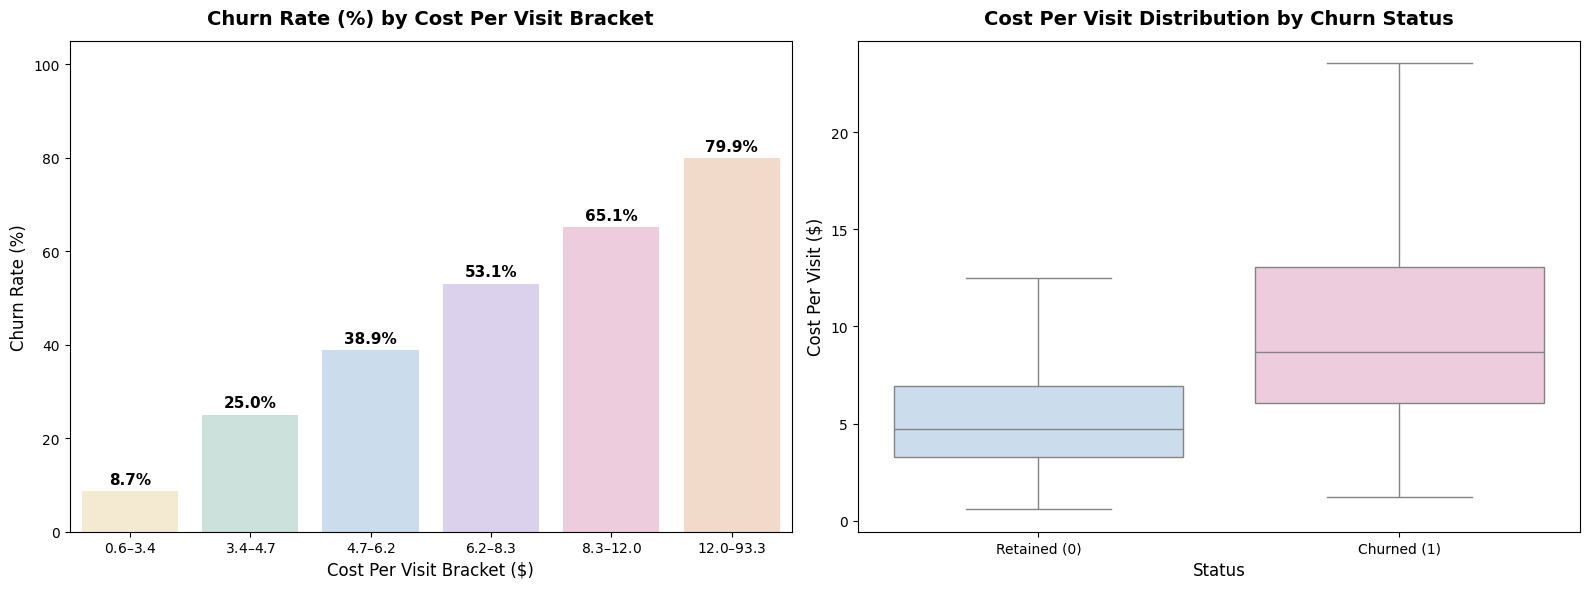

In [269]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# ==========================================
# 🎨 YOUR PASTEL HEX PALETTE
# ==========================================
my_hex_colors = [
    '#FAEDCB',  # 1. Warm Cream
    '#C9E4DE',  # 2. Soft Mint
    '#C6DEF1',  # 3. Light Periwinkle Blue
    '#DBCDF0',  # 4. Lavender
    '#F2C6DE',  # 5. Soft Pink
    '#F7D9C4',  # 6. Peach
]
# ==========================================

# 1. Bin cost_per_visit into 6 quantile tiers to match your 6 colors
data['cost_tier'] = pd.qcut(data['cost_per_visit'], q=6)
data['cost_bracket'] = data['cost_tier'].apply(
    lambda x: f'${x.left:.1f}–${x.right:.1f}'
)

tier_order = (
    data.groupby('cost_bracket', observed=False)['cost_per_visit']
    .mean()
    .sort_values()
    .index.tolist()
)

# 2. Calculate churn percentage per bracket
cost_summary = (
    data.groupby('cost_bracket', observed=False)['churned_by_february']
    .agg(total_members='count', churn_rate='mean')
    .reset_index()
)
cost_summary['churn_rate_pct'] = cost_summary['churn_rate'] * 100

# 3. Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left Plot: Churn Rate (%) using all 6 HEX colors ---
sns.barplot(
    data=cost_summary,
    x='cost_bracket',
    y='churn_rate_pct',
    order=tier_order,
    palette=my_hex_colors,  # Pass all 6 HEX colors
    ax=axes[0],
)
axes[0].set_title(
    'Churn Rate (%) by Cost Per Visit Bracket',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
axes[0].set_xlabel('Cost Per Visit Bracket ($)', fontsize=12)
axes[0].set_ylabel('Churn Rate (%)', fontsize=12)
axes[0].set_ylim(0, 105)

# Annotate exact percentages above bars
for p in axes[0].patches:
  height = p.get_height()
  axes[0].annotate(
      f'{height:.1f}%',
      (p.get_x() + p.get_width() / 2.0, height),
      ha='center',
      va='bottom',
      fontsize=11,
      fontweight='bold',
      xytext=(0, 3),
      textcoords='offset points',
  )

# --- Right Plot: Retained (Blue) vs Churned (Pink) ---
sns.boxplot(
    data=data,
    x='churned_by_february',
    y='cost_per_visit',
    palette=['#C6DEF1', '#F2C6DE'],  # Retained = Blue, Churned = Pink
    ax=axes[1],
    showfliers=False,
)
axes[1].set_title(
    'Cost Per Visit Distribution by Churn Status',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
axes[1].set_xlabel('Status', fontsize=12)
axes[1].set_ylabel('Cost Per Visit ($)', fontsize=12)
axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_58/3444096449.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_58/3444096449.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])
/tmp/ipykernel_58/3444096449.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_58/3444096449.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])
/tmp/ipykernel_58/3444096449.py:28: FutureWarning: 

Passing `palette` without assignin

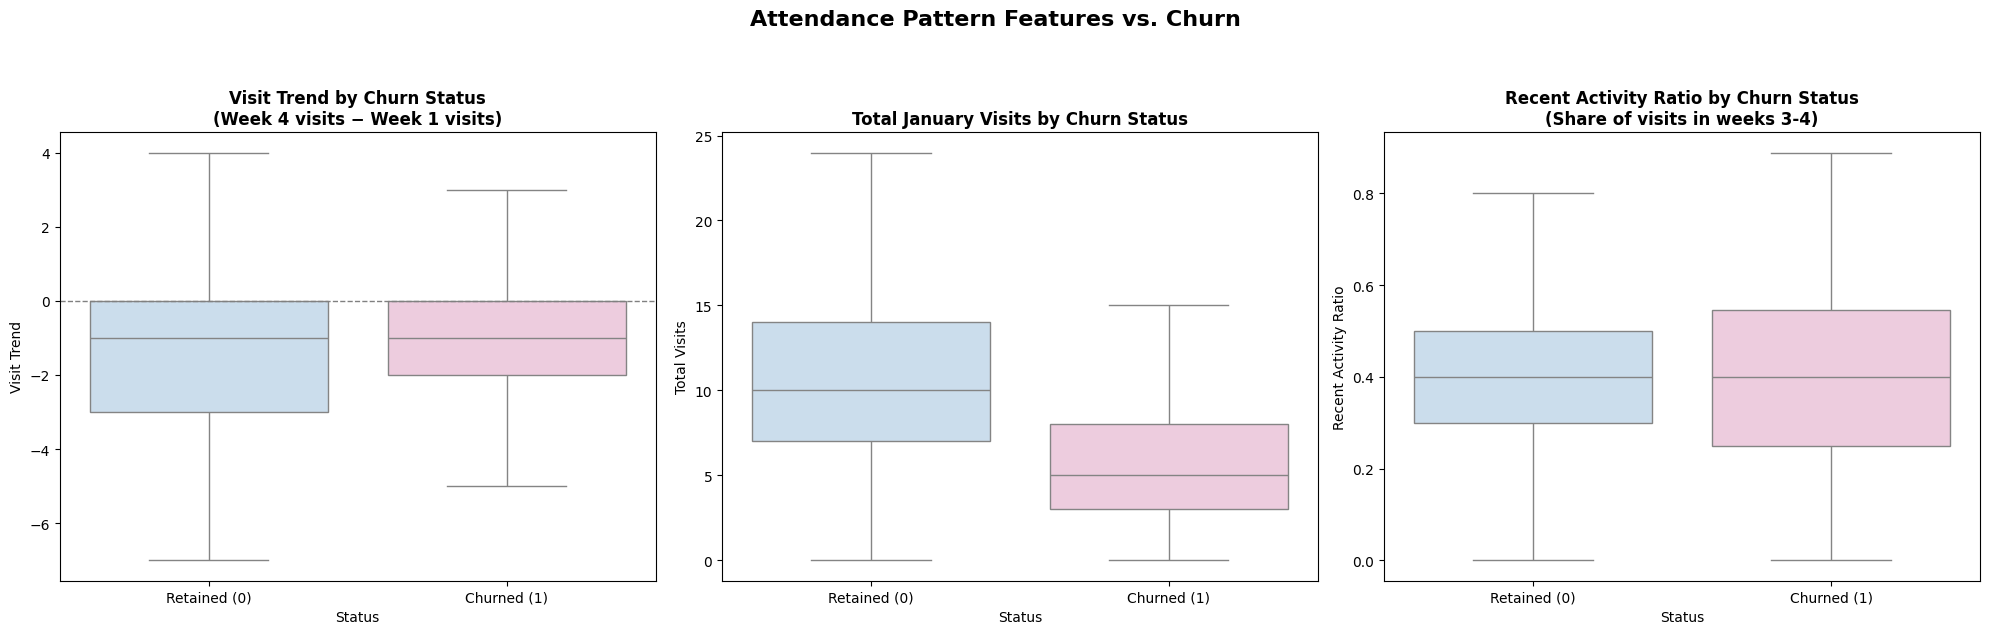

In [270]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

retained_hex = '#C6DEF1'  # Soft Blue for Retained (0)
churned_hex = '#F2C6DE'   # Soft Pink for Churned (1)

# 1. Visit Trend: did attendance rise or fall across the month?
sns.boxplot(
    data=data, x='churned_by_february', y='visit_trend',
    palette=[retained_hex, churned_hex], ax=axes[0], showfliers=False
)
axes[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Visit Trend by Churn Status\n(Week 4 visits − Week 1 visits)', fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Visit Trend')
axes[0].set_xticklabels(['Retained (0)', 'Churned (1)'])

# 2. Total Visits: overall engagement volume
sns.boxplot(
    data=data, x='churned_by_february', y='total_visits',
    palette=[retained_hex, churned_hex], ax=axes[1], showfliers=False
)
axes[1].set_title('Total January Visits by Churn Status', fontweight='bold')
axes[1].set_xlabel('Status')
axes[1].set_ylabel('Total Visits')
axes[1].set_xticklabels(['Retained (0)', 'Churned (1)'])

# 3. Recent Activity Ratio: front-loaded vs. back-loaded attendance
sns.boxplot(
    data=data, x='churned_by_february', y='recent_activity_ratio',
    palette=[retained_hex, churned_hex], ax=axes[2], showfliers=False
)
axes[2].set_title('Recent Activity Ratio by Churn Status\n(Share of visits in weeks 3-4)', fontweight='bold')
axes[2].set_xlabel('Status')
axes[2].set_ylabel('Recent Activity Ratio')
axes[2].set_xticklabels(['Retained (0)', 'Churned (1)'])

plt.suptitle('Attendance Pattern Features vs. Churn', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [271]:
feature_engineering_cols = ['visit_trend', 'total_visits', 'recent_activity_ratio', 'engagement_score', 'cost_per_visit']

feature_engineering_df = data[feature_engineering_cols].copy()

# data = data.drop(columns=feature_engineering_cols)

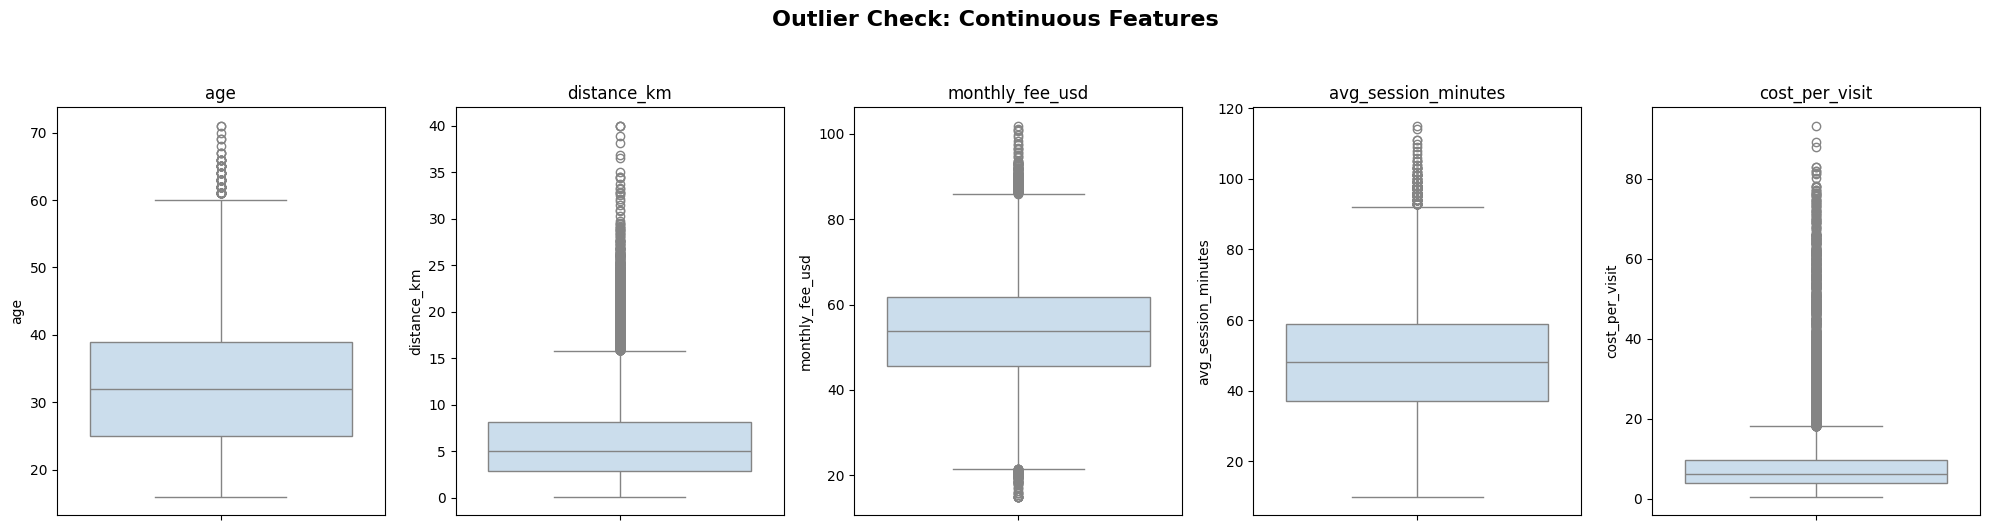

In [272]:
outlier_check_cols = ['age', 'distance_km', 'monthly_fee_usd', 'avg_session_minutes', 'cost_per_visit']

fig, axes = plt.subplots(1, len(outlier_check_cols), figsize=(20, 5))
for i, col in enumerate(outlier_check_cols):
    sns.boxplot(data=data, y=col, ax=axes[i], color='#C6DEF1')
    axes[i].set_title(col)
plt.suptitle("Outlier Check: Continuous Features", fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [273]:
def cap_outliers_iqr(df, col, factor=1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)
    return df

for col in ['distance_km', 'cost_per_visit']:
    data = cap_outliers_iqr(data, col)

# **3.Cleaning Data**

In [274]:
data=data.drop(columns=['member_id'])
data

,age,sex,distance_km,prior_gym_experience,joined_with_friend,contract_type,monthly_fee_usd,signup_week_january,promo_used,primary_goal,...,guest_passes_used,locker_rented,churned_by_february,visit_trend,total_visits,recent_activity_ratio,engagement_score,cost_per_visit,cost_tier,cost_bracket
0,40,F,6.6,1,0,6_month,47.07,1,0,general_health,...,1,0,1,-2,7,0.285714,0,5.883750,"(4.748, 6.24]",$4.7–$6.2
1,55,F,3.8,0,0,month_to_month,62.59,4,1,weight_loss,...,0,0,1,0,9,0.444444,0,6.259000,"(6.24, 8.27]",$6.2–$8.3
2,26,F,3.9,0,0,annual,36.68,2,1,muscle_gain,...,1,1,1,-1,3,0.666664,2,9.170000,"(8.27, 11.97]",$8.3–$12.0
3,20,M,0.4,0,0,annual,51.52,1,0,muscle_gain,...,0,0,0,-3,16,0.312500,2,3.030588,"(0.578, 3.409]",$0.6–$3.4
4,47,M,0.4,0,0,month_to_month,57.02,4,0,muscle_gain,...,1,1,1,0,6,0.333333,2,8.145714,"(6.24, 8.27]",$6.2–$8.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,23,M,12.1,1,0,month_to_month,66.65,2,0,general_health,...,0,1,0,-3,13,0.461538,2,4.760714,"(4.748, 6.24]",$4.7–$6.2
49996,37,M,6.1,0,0,month_to_month,66.93,2,0,weight_loss,...,2,1,0,-4,5,0.200000,2,11.155000,"(8.27, 11.97]",$8.3–$12.0
49997,57,M,1.9,0,0,month_to_month,56.98,2,1,muscle_gain,...,0,0,0,-3,4,0.000000,0,11.396000,"(8.27, 11.97]",$8.3–$12.0
49998,31,Other,4.7,0,1,6_month,52.95,2,0,weight_loss,...,0,0,0,2,16,0.625000,2,3.114706,"(0.578, 3.409]",$0.6–$3.4


In [275]:
print('\nMissing values:')
data.isnull().sum()


Missing values:


age                      0
sex                      0
distance_km              0
prior_gym_experience     0
joined_with_friend       0
contract_type            0
monthly_fee_usd          0
signup_week_january      0
promo_used               0
primary_goal             0
goal_aggressiveness      0
week1_visits             0
week2_visits             0
week3_visits             0
week4_visits             0
avg_weekly_classes       0
booked_induction         0
personal_trainer         0
app_installed            0
avg_session_minutes      0
guest_passes_used        0
locker_rented            0
churned_by_february      0
visit_trend              0
total_visits             0
recent_activity_ratio    0
engagement_score         0
cost_per_visit           0
cost_tier                0
cost_bracket             0
dtype: int64

In [276]:
print('\nDuplicate values:')
data.duplicated().sum()


Duplicate values:


np.int64(0)

In [277]:
print('Category Classification: ')
data['monthly_fee_usd'].value_counts()

Category Classification: 


monthly_fee_usd
50.04    31
49.48    31
53.96    30
53.91    29
59.48    29
         ..
31.51     1
29.63     1
86.72     1
23.16     1
30.75     1
Name: count, Length: 5927, dtype: int64

In [278]:
print('Category Classification: ')
data['primary_goal'].value_counts()

Category Classification: 


primary_goal
weight_loss       22860
general_health    12026
muscle_gain       11000
event_prep         4114
Name: count, dtype: int64

# **4.Data Encoding**

In [279]:
encode_col = ['contract_type', 'sex','primary_goal']
data = pd.get_dummies(data, columns=encode_col, drop_first=True, dtype=int)

data

,age,distance_km,prior_gym_experience,joined_with_friend,monthly_fee_usd,signup_week_january,promo_used,goal_aggressiveness,week1_visits,week2_visits,...,cost_per_visit,cost_tier,cost_bracket,contract_type_annual,contract_type_month_to_month,sex_M,sex_Other,primary_goal_general_health,primary_goal_muscle_gain,primary_goal_weight_loss
0,40,6.6,1,0,47.07,1,0,3,3,2,...,5.883750,"(4.748, 6.24]",$4.7–$6.2,0,0,0,0,1,0,0
1,55,3.8,0,0,62.59,4,1,1,2,3,...,6.259000,"(6.24, 8.27]",$6.2–$8.3,0,1,0,0,0,0,1
2,26,3.9,0,0,36.68,2,1,5,1,0,...,9.170000,"(8.27, 11.97]",$8.3–$12.0,1,0,0,0,0,1,0
3,20,0.4,0,0,51.52,1,0,5,6,5,...,3.030588,"(0.578, 3.409]",$0.6–$3.4,1,0,1,0,0,1,0
4,47,0.4,0,0,57.02,4,0,1,1,3,...,8.145714,"(6.24, 8.27]",$6.2–$8.3,0,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,23,12.1,1,0,66.65,2,0,4,4,3,...,4.760714,"(4.748, 6.24]",$4.7–$6.2,0,1,1,0,1,0,0
49996,37,6.1,0,0,66.93,2,0,5,4,0,...,11.155000,"(8.27, 11.97]",$8.3–$12.0,0,1,1,0,0,0,1
49997,57,1.9,0,0,56.98,2,1,2,3,1,...,11.396000,"(8.27, 11.97]",$8.3–$12.0,0,1,1,0,0,1,0
49998,31,4.7,0,1,52.95,2,0,2,2,4,...,3.114706,"(0.578, 3.409]",$0.6–$3.4,0,0,0,1,0,0,1


# **5.Data Splitting**

In [280]:
non_numeric_eda_cols = ['cost_tier', 'cost_bracket']

# Safely drop them if they exist in data
x = data.drop(columns=['churned_by_february'] + [col for col in non_numeric_eda_cols if col in data.columns])
y = data['churned_by_february']

In [281]:
print('x: ', x.shape)
print('y: ', y.shape)

x:  (50000, 31)
y:  (50000,)


In [282]:
from sklearn.model_selection import train_test_split

x_train, x_temp, y_train, y_temp = train_test_split(x, 
                                                    y, 
                                                    test_size=0.30, 
                                                    random_state=42,
                                                    stratify=y
                                                   )

x_val, x_test, y_val, y_test = train_test_split(x_temp, 
                                                y_temp, 
                                                test_size=0.50, 
                                                random_state=42,
                                                stratify=y_temp
                                               )

In [283]:
print("Training:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Testing:", x_test.shape, y_test.shape)

Training: (35000, 31) (35000,)
Validation: (7500, 31) (7500,)
Testing: (7500, 31) (7500,)


# **6.Data Scaling**

In [284]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

standard_scaler.fit(x_train)

x_train_st = standard_scaler.transform(x_train)
x_val_st= standard_scaler.transform(x_val)
x_test_st = standard_scaler.transform(x_test)

In [285]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

minmax_scaler.fit(x_train)

x_train_mm = minmax_scaler.transform(x_train)
x_val_mm = minmax_scaler.transform(x_val)
x_test_mm = minmax_scaler.transform(x_test)

In [286]:
print(data['contract_type'].unique() if 'contract_type' in data.columns else og['contract_type'].unique())
print(og['sex'].unique())

['6_month' 'month_to_month' 'annual']
['F' 'M' 'Other']


# **7.Machine Learning Models**

**Logistic Regression:**

a. standard scaler

In [287]:
from sklearn.linear_model import LogisticRegression

logistic_model=LogisticRegression()

logistic_model.fit(x_train_st, y_train)

LogisticRegression()

In [288]:
y_train_st_pred_lr = logistic_model.predict(x_train_st)
y_val_st_pred_lr = logistic_model.predict(x_val_st)
y_test_st_pred_lr = logistic_model.predict(x_test_st)

In [289]:
probab_pred_st_lr=logistic_model.predict_proba(x_test_st)

In [290]:
compare_test_df_lr_st = pd.DataFrame({
    'actual': y_test.values,
    'test_prediction': y_test_st_pred_lr,
})

compare_test_df_lr_st

,actual,test_prediction
0,0,0
1,0,0
2,1,1
3,0,0
4,1,1
...,...,...
7495,0,0
7496,0,0
7497,0,0
7498,1,1


In [291]:
compare_val_df_lr_st = pd.DataFrame({
    'actual': y_val.values,
    'val_prediction': y_val_st_pred_lr,
})

compare_val_df_lr_st

,actual,val_prediction
0,1,1
1,0,1
2,0,0
3,0,1
4,1,1
...,...,...
7495,0,0
7496,1,1
7497,1,1
7498,0,0


In [292]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

train_accuracy_st_lr = accuracy_score(y_train, y_train_st_pred_lr)
val_accuracy_st_lr   = accuracy_score(y_val, y_val_st_pred_lr)
test_accuracy_st_lr  = accuracy_score(y_test, y_test_st_pred_lr)

print("Training Accuracy: ", train_accuracy_st_lr)
print("Validation Accuracy: ", val_accuracy_st_lr)
print("Testing Accuracy: ", test_accuracy_st_lr)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_st_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_test_st_pred_lr))

Training Accuracy:  0.7492571428571428
Validation Accuracy:  0.7468
Testing Accuracy:  0.7410666666666667

Confusion Matrix:
[[3117  999]
 [ 943 2441]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.76      4116
           1       0.71      0.72      0.72      3384

    accuracy                           0.74      7500
   macro avg       0.74      0.74      0.74      7500
weighted avg       0.74      0.74      0.74      7500



b. minmax scaler

In [293]:
logistic_model_mm=LogisticRegression()

logistic_model_mm.fit(x_train_mm, y_train)

LogisticRegression()

In [294]:
y_train_mm_pred_lr = logistic_model_mm.predict(x_train_mm)
y_val_mm_pred_lr = logistic_model_mm.predict(x_val_mm)
y_test_mm_pred_lr = logistic_model_mm.predict(x_test_mm)

In [295]:
probab_pred_mm_lr=logistic_model_mm.predict_proba(x_test_mm)

In [296]:
compare_test_df_lr_mm = pd.DataFrame({
    'actual': y_test.values,
    'test_prediction': y_test_mm_pred_lr,
})

compare_test_df_lr_mm

,actual,test_prediction
0,0,0
1,0,0
2,1,1
3,0,0
4,1,1
...,...,...
7495,0,0
7496,0,0
7497,0,0
7498,1,1


In [297]:
compare_val_df_lr_mm = pd.DataFrame({
    'actual': y_val.values,
    'val_prediction': y_val_mm_pred_lr,
})

compare_val_df_lr_mm

,actual,val_prediction
0,1,1
1,0,1
2,0,0
3,0,1
4,1,1
...,...,...
7495,0,0
7496,1,1
7497,1,1
7498,0,0


In [298]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

train_accuracy_mm_lr = accuracy_score(y_train, y_train_mm_pred_lr)
val_accuracy_mm_lr   = accuracy_score(y_val, y_val_mm_pred_lr)
test_accuracy_mm_lr  = accuracy_score(y_test, y_test_mm_pred_lr)

print("Training Accuracy: ", train_accuracy_mm_lr)
print("Validation Accuracy: ", val_accuracy_mm_lr)
print("Testing Accuracy: ", test_accuracy_mm_lr)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_mm_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_test_mm_pred_lr))

Training Accuracy:  0.7494285714285714
Validation Accuracy:  0.7464
Testing Accuracy:  0.7413333333333333

Confusion Matrix:
[[3124  992]
 [ 948 2436]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.76      4116
           1       0.71      0.72      0.72      3384

    accuracy                           0.74      7500
   macro avg       0.74      0.74      0.74      7500
weighted avg       0.74      0.74      0.74      7500



**----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------**

**Decision tree**

In [299]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model=DecisionTreeClassifier(
    
    criterion='entropy',
    
    max_depth=5,
    
    min_samples_leaf=10,
    
    min_samples_split=20,
    
    random_state=42
    
)

decision_tree_model.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=10,
                       min_samples_split=20, random_state=42)

In [300]:
y_train_pred_dt = decision_tree_model.predict(x_train)
y_val_pred_dt = decision_tree_model.predict(x_val)
y_test_pred_dt = decision_tree_model.predict(x_test)

In [301]:
probab_pred_dt=decision_tree_model.predict_proba(x_test)

In [302]:
compare_test_df_dt = pd.DataFrame({
    'actual': y_test.values,
    'test_prediction': y_test_pred_dt,
})

compare_test_df_dt

,actual,test_prediction
0,0,0
1,0,0
2,1,1
3,0,0
4,1,1
...,...,...
7495,0,0
7496,0,0
7497,0,0
7498,1,1


In [303]:
compare_val_df_dt = pd.DataFrame({
    'actual': y_val.values,
    'val_prediction': y_val_pred_dt,
})

compare_val_df_dt

,actual,val_prediction
0,1,1
1,0,1
2,0,0
3,0,1
4,1,1
...,...,...
7495,0,0
7496,1,1
7497,1,1
7498,0,1


In [304]:
train_accuracy_dt = accuracy_score(y_train, y_train_pred_dt)
val_accuracy_dt   = accuracy_score(y_val, y_val_pred_dt)
test_accuracy_dt  = accuracy_score(y_test, y_test_pred_dt)

print("Training Accuracy: ", train_accuracy_dt)
print("Validation Accuracy: ", val_accuracy_dt)
print("Testing Accuracy: ", test_accuracy_dt)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_dt))

Training Accuracy:  0.7304
Validation Accuracy:  0.7277333333333333
Testing Accuracy:  0.722

Confusion Matrix:
[[3186  930]
 [1155 2229]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.77      0.75      4116
           1       0.71      0.66      0.68      3384

    accuracy                           0.72      7500
   macro avg       0.72      0.72      0.72      7500
weighted avg       0.72      0.72      0.72      7500



**----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------**

**K Nearest Neighbours (KNN)**

a. standard scaler

In [305]:
from sklearn.neighbors import KNeighborsClassifier

knn_model=KNeighborsClassifier(n_neighbors=5)

knn_model.fit(x_train_st, y_train)

KNeighborsClassifier()

In [306]:
y_train_st_pred_knn = knn_model.predict(x_train_st)
y_val_st_pred_knn = knn_model.predict(x_val_st)
y_test_st_pred_knn = knn_model.predict(x_test_st)

In [307]:
probab_pred_st_knn=knn_model.predict_proba(x_test_st)

In [308]:
compare_test_df_knn_st = pd.DataFrame({
    'actual': y_test.values,
    'test_prediction': y_test_st_pred_knn,
})

compare_test_df_knn_st

,actual,test_prediction
0,0,0
1,0,0
2,1,1
3,0,1
4,1,1
...,...,...
7495,0,0
7496,0,0
7497,0,0
7498,1,1


In [309]:
compare_val_df_knn_st = pd.DataFrame({
    'actual': y_val.values,
    'val_prediction': y_val_st_pred_knn,
})

compare_val_df_knn_st

,actual,val_prediction
0,1,1
1,0,0
2,0,0
3,0,1
4,1,1
...,...,...
7495,0,0
7496,1,0
7497,1,0
7498,0,1


In [310]:
train_accuracy_st_knn = accuracy_score(y_train, y_train_st_pred_knn)
val_accuracy_st_knn = accuracy_score(y_val, y_val_st_pred_knn)
test_accuracy_st_knn = accuracy_score(y_test, y_test_st_pred_knn)

print("Training Accuracy: ", train_accuracy_st_knn)
print("Validation Accuracy: ", val_accuracy_st_knn)
print("Testing Accuracy: ", test_accuracy_st_knn)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_st_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_test_st_pred_knn))

Training Accuracy:  0.7913428571428571
Validation Accuracy:  0.692
Testing Accuracy:  0.6766666666666666

Confusion Matrix:
[[2843 1273]
 [1152 2232]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.69      0.70      4116
           1       0.64      0.66      0.65      3384

    accuracy                           0.68      7500
   macro avg       0.67      0.68      0.67      7500
weighted avg       0.68      0.68      0.68      7500



b. minmax scaler

In [311]:
knn_model =KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_mm, y_train)

y_train_mm_pred_knn = knn_model.predict(x_train_mm)
y_val_mm_pred_knn = knn_model.predict(x_val_mm)
y_test_mm_pred_knn = knn_model.predict(x_test_mm)

In [312]:
probab_pred_mm_knn=knn_model.predict_proba(x_test_mm)

In [313]:
compare_test_df_knn_mm = pd.DataFrame({
    'actual': y_test.values,
    'test_prediction': y_test_mm_pred_knn,
})

compare_test_df_knn_mm

,actual,test_prediction
0,0,0
1,0,1
2,1,0
3,0,0
4,1,1
...,...,...
7495,0,0
7496,0,0
7497,0,0
7498,1,0


In [314]:
compare_val_df_knn_mm = pd.DataFrame({
    'actual': y_val.values,
    'val_prediction': y_val_mm_pred_knn,
})

compare_val_df_knn_mm

,actual,val_prediction
0,1,1
1,0,0
2,0,1
3,0,1
4,1,1
...,...,...
7495,0,0
7496,1,1
7497,1,0
7498,0,0


In [315]:
train_accuracy_mm_knn = accuracy_score(y_train, y_train_mm_pred_knn)
val_accuracy_mm_knn = accuracy_score(y_val, y_val_mm_pred_knn)
test_accuracy_mm_knn = accuracy_score(y_test, y_test_mm_pred_knn)

print("Training Accuracy: ", train_accuracy_mm_knn)
print("Validation Accuracy: ", val_accuracy_mm_knn)
print("Testing Accuracy: ", test_accuracy_mm_knn)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_mm_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_test_mm_pred_knn))

Training Accuracy:  0.7739428571428572
Validation Accuracy:  0.6564
Testing Accuracy:  0.6425333333333333

Confusion Matrix:
[[2844 1272]
 [1409 1975]]

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.69      0.68      4116
           1       0.61      0.58      0.60      3384

    accuracy                           0.64      7500
   macro avg       0.64      0.64      0.64      7500
weighted avg       0.64      0.64      0.64      7500



**----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------**

**Support Vector Machine (SVM)**

**Random Forest**

a. standard scaler

In [316]:
# from sklearn.svm import SVC

# svm_model = SVC(kernel='rbf', probability=True)

# svm_model.fit(x_train_st, y_train)

In [317]:
# y_train_st_pred_svm = svm_model.predict(x_train_st)
# y_val_st_pred_svm = svm_model.predict(x_val_st)
# y_test_st_pred_svm = svm_model.predict(x_test_st)

In [318]:
# probab_pred_st_svm=svm_model.predict_proba(x_test_st)

In [319]:
# compare_test_df_svm_st = pd.DataFrame({
#     'actual': y_test.values,
#     'test_prediction': y_test_st_pred_svm,
# })

# compare_test_df_svm_st

In [320]:
# compare_val_df_svm_st = pd.DataFrame({
#     'actual': y_val.values,
#     'val_prediction': y_val_st_pred_svm,
# })

# compare_val_df_svm_st

In [321]:
# train_accuracy_st_svm = accuracy_score(y_train, y_train_st_pred_svm)
# val_accuracy_st_svm = accuracy_score(y_val, y_val_st_pred_svm)
# test_accuracy_st_svm = accuracy_score(y_test, y_test_st_pred_svm)

# print("Training Accuracy: ", train_accuracy_st_svm)
# print("Validation Accuracy: ", val_accuracy_st_svm)
# print("Testing Accuracy: ", test_accuracy_st_svm)

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_test_st_pred_svm))

# print("\nClassification Report:")
# print(classification_report(y_test, y_test_st_pred_svm))

b. minmax scaler

In [322]:
# svm_model = SVC(kernel='rbf', probability=True)

# svm_model.fit(x_train_mm, y_train)

In [323]:
# y_train_mm_pred_svm = svm_model.predict(x_train_mm)
# y_val_mm_pred_svm = svm_model.predict(x_val_mm)
# y_test_mm_pred_svm = svm_model.predict(x_test_mm)

In [324]:
# probab_pred_mm_svm=svm_model.predict_proba(x_test_mm)

In [325]:
# compare_test_df_svm_mm = pd.DataFrame({
#     'actual': y_test.values,
#     'test_prediction': y_test_mm_pred_svm,
# })

# compare_test_df_svm_mm

In [326]:
# compare_val_df_svm_mm = pd.DataFrame({
#     'actual': y_val.values,
#     'val_prediction': y_val_mm_pred_svm,
# })

# compare_val_df_svm_mm

In [327]:
# train_accuracy_mm_svm = accuracy_score(y_train, y_train_mm_pred_svm)
# val_accuracy_mm_svm = accuracy_score(y_val, y_val_mm_pred_svm)
# test_accuracy_mm_svm = accuracy_score(y_test, y_test_mm_pred_svm)

# print("Training Accuracy: ", train_accuracy_mm_svm)
# print("Validation Accuracy: ", val_accuracy_mm_svm)
# print("Testing Accuracy: ", test_accuracy_mm_svm)

# print("\nConfusion Matrix:")
# print(confusion_matrix(y_test, y_test_mm_pred_svm))

# print("\nClassification Report:")
# print(classification_report(y_test, y_test_mm_pred_svm))

**----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------**

In [328]:
from sklearn.ensemble import RandomForestClassifier

rf_model=RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    oob_score=True,
    random_state=42  
)

rf_model.fit(x_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, n_estimators=300,
                       oob_score=True, random_state=42)

In [329]:
y_train_pred_rf = rf_model.predict(x_train)
y_val_pred_rf = rf_model.predict(x_val)
y_test_pred_rf = rf_model.predict(x_test)

In [330]:
probab_pred_rf=rf_model.predict_proba(x_test)

In [331]:
compare_test_df_rf = pd.DataFrame({
    'actual': y_test.values,
    'test_prediction': y_test_pred_rf,
})

compare_test_df_rf

,actual,test_prediction
0,0,0
1,0,0
2,1,1
3,0,0
4,1,1
...,...,...
7495,0,0
7496,0,0
7497,0,0
7498,1,1


In [332]:
compare_val_df_rf = pd.DataFrame({
    'actual': y_val.values,
    'val_prediction': y_val_pred_rf,
})

compare_val_df_rf

,actual,val_prediction
0,1,1
1,0,1
2,0,0
3,0,1
4,1,1
...,...,...
7495,0,0
7496,1,1
7497,1,1
7498,0,1


In [333]:
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)

print("Training Accuracy: ", train_accuracy_rf)
print("Validation Accuracy: ", val_accuracy_rf)
print("Testing Accuracy: ", test_accuracy_rf)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf))

Training Accuracy:  0.7822857142857143
Validation Accuracy:  0.7392
Testing Accuracy:  0.7370666666666666

Confusion Matrix:
[[3105 1011]
 [ 961 2423]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.75      0.76      4116
           1       0.71      0.72      0.71      3384

    accuracy                           0.74      7500
   macro avg       0.73      0.74      0.73      7500
weighted avg       0.74      0.74      0.74      7500



**--------------------------------------------------------------------------------------------------------------------------------------------------------**

**XGBClassifier**

a. standard scaler

In [334]:
from xgboost import XGBClassifier

xgb_model_st = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

xgb_model_st.fit(x_train_st, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [335]:
y_train_pred_xgb_st = xgb_model_st.predict(x_train_st)
y_val_pred_xgb_st = xgb_model_st.predict(x_val_st)
y_test_pred_xgb_st = xgb_model_st.predict(x_test_st)

In [336]:
probab_pred_xgb_st=xgb_model_st.predict_proba(x_test_st)

In [337]:
compare_test_df_xgb_st = pd.DataFrame({
    'actual': y_test.values,
    'test_prediction': y_test_pred_xgb_st,
})

compare_test_df_xgb_st

,actual,test_prediction
0,0,0
1,0,0
2,1,1
3,0,0
4,1,1
...,...,...
7495,0,0
7496,0,0
7497,0,0
7498,1,1


In [338]:
compare_val_df_xgb_st = pd.DataFrame({
    'actual': y_test.values,
    'test_prediction': y_val_pred_xgb_st,
})

compare_val_df_xgb_st

,actual,test_prediction
0,0,1
1,0,1
2,1,0
3,0,1
4,1,1
...,...,...
7495,0,0
7496,0,1
7497,0,1
7498,1,1


In [339]:
train_accuracy_xgb_st = accuracy_score(y_train, y_train_pred_xgb_st)
val_accuracy_xgb_st = accuracy_score(y_val, y_val_pred_xgb_st)
test_accuracy_xgb_st = accuracy_score(y_test, y_test_pred_xgb_st)

print("Training Accuracy: ", train_accuracy_xgb_st)
print("Validation Accuracy: ", val_accuracy_xgb_st)
print("Testing Accuracy: ", test_accuracy_xgb_st)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_xgb_st))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_xgb_st))

Training Accuracy:  0.7532285714285715
Validation Accuracy:  0.7437333333333334
Testing Accuracy:  0.74

Confusion Matrix:
[[3109 1007]
 [ 943 2441]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.76      4116
           1       0.71      0.72      0.71      3384

    accuracy                           0.74      7500
   macro avg       0.74      0.74      0.74      7500
weighted avg       0.74      0.74      0.74      7500



b. minmax scaler

In [340]:
xgb_model_mm = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

xgb_model_mm.fit(x_train_mm, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [341]:
y_train_pred_xgb_mm = xgb_model_mm.predict(x_train_mm)
y_val_pred_xgb_mm = xgb_model_mm.predict(x_val_mm)
y_test_pred_xgb_mm = xgb_model_mm.predict(x_test_mm)

In [342]:
probab_pred_xgb_mm=xgb_model_mm.predict_proba(x_test_mm)

In [343]:
compare_test_df_xgb_mm = pd.DataFrame({
    'actual': y_test.values,
    'test_prediction': y_test_pred_xgb_mm,
})

compare_test_df_xgb_mm

,actual,test_prediction
0,0,0
1,0,0
2,1,1
3,0,0
4,1,1
...,...,...
7495,0,0
7496,0,0
7497,0,0
7498,1,1


In [344]:
compare_val_df_xgb_mm = pd.DataFrame({
    'actual': y_test.values,
    'test_prediction': y_val_pred_xgb_mm,
})

compare_val_df_xgb_mm

,actual,test_prediction
0,0,1
1,0,1
2,1,0
3,0,1
4,1,1
...,...,...
7495,0,0
7496,0,1
7497,0,1
7498,1,1


In [345]:
train_accuracy_xgb_mm = accuracy_score(y_train, y_train_pred_xgb_mm)
val_accuracy_xgb_mm = accuracy_score(y_val, y_val_pred_xgb_mm)
test_accuracy_xgb_mm = accuracy_score(y_test, y_test_pred_xgb_mm)

print("Training Accuracy: ", train_accuracy_xgb_mm)
print("Validation Accuracy: ", val_accuracy_xgb_mm)
print("Testing Accuracy: ", test_accuracy_xgb_mm)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_xgb_mm))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_xgb_mm))

Training Accuracy:  0.7532285714285715
Validation Accuracy:  0.7437333333333334
Testing Accuracy:  0.74

Confusion Matrix:
[[3109 1007]
 [ 943 2441]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.76      4116
           1       0.71      0.72      0.71      3384

    accuracy                           0.74      7500
   macro avg       0.74      0.74      0.74      7500
weighted avg       0.74      0.74      0.74      7500



# **8. Deep Learning Model**

**Neural Network**

a. standard scaler

In [346]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, BatchNormalization, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint

deep_model_st = Sequential([
    Input(shape=(x_train.shape[1],)),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

deep_model_st.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 256)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,249 (208.00 KB)

 Trainable params: 52,353 (204.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [347]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

deep_model_st.compile(

    optimizer=Adam(learning_rate=0.0005),

    loss='binary_crossentropy',

    metrics=['accuracy']
    
)

In [348]:
checkpoint = ModelCheckpoint(
    
    filepath='best_model.keras', 
    
    monitor='val_loss', 
    
    save_best_only=True
)

In [349]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=22,
    restore_best_weights=True
)

In [350]:
history_deep_st=deep_model_st.fit(

    x_train_st,

    y_train,

    validation_data=(x_val_st, y_val),

    epochs=500,

    batch_size=64,
    
    callbacks=[early_stopping, checkpoint]
    
)

Epoch 1/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7078 - loss: 0.5663 - val_accuracy: 0.7440 - val_loss: 0.5177
Epoch 2/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7328 - loss: 0.5290 - val_accuracy: 0.7428 - val_loss: 0.5114
Epoch 3/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7410 - loss: 0.5190 - val_accuracy: 0.7456 - val_loss: 0.5132
Epoch 4/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7422 - loss: 0.5154 - val_accuracy: 0.7464 - val_loss: 0.5100
Epoch 5/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7425 - loss: 0.5132 - val_accuracy: 0.7475 - val_loss: 0.5094
Epoch 6/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7455 - loss: 0.5107 - val_accuracy: 0.7483 - val_loss: 0.5098
Epoch 7/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7465 - loss: 0.5112 - val_accuracy: 0.7483 - val_loss: 0.5094
Epoch 8/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7462 - loss: 0.5084 - val_accu

In [351]:
deep_preds_st = deep_model_st.predict(x_test_st)

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [352]:
from sklearn.metrics import classification_report, confusion_matrix
deep_preds_st_binary = (deep_preds_st > 0.5).astype(int)
print(confusion_matrix(y_test, deep_preds_st_binary))
print(classification_report(y_test, deep_preds_st_binary))

[[3099 1017]
 [ 967 2417]]
              precision    recall  f1-score   support

           0       0.76      0.75      0.76      4116
           1       0.70      0.71      0.71      3384

    accuracy                           0.74      7500
   macro avg       0.73      0.73      0.73      7500
weighted avg       0.74      0.74      0.74      7500



In [353]:
deep_loss_st, deep_accuracy_st = deep_model_st.evaluate(x_test_st, y_test)

print(f"Deep NN Test Accuracy: {deep_accuracy_st:.4f}")
print(f"Deep NN Test Loss:     {deep_loss_st:.4f}")

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7355 - loss: 0.5185
Deep NN Test Accuracy: 0.7355
Deep NN Test Loss:     0.5185


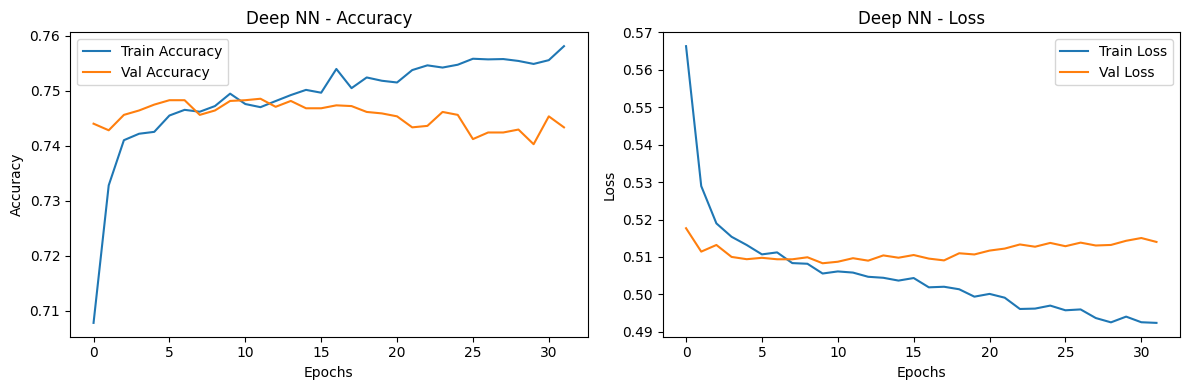

In [354]:
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_deep_st.history['accuracy'], label='Train Accuracy')
plt.plot(history_deep_st.history['val_accuracy'], label='Val Accuracy')
plt.title('Deep NN - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_deep_st.history['loss'], label='Train Loss')
plt.plot(history_deep_st.history['val_loss'], label='Val Loss')
plt.title('Deep NN - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

b. minmax scaler

In [355]:
deep_model_mm = Sequential([
    Input(shape=(x_train.shape[1],)),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

deep_model_mm.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 256)            │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,249 (208.00 KB)

 Trainable params: 52,353 (204.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [356]:
deep_model_mm.compile(

    optimizer=Adam(learning_rate=0.0005),

    loss='binary_crossentropy',

    metrics=['accuracy']
    
)

In [357]:
history_deep_mm=deep_model_mm.fit(

    x_train_mm,

    y_train,

    validation_data=(x_val_mm, y_val),

    epochs=500,

    batch_size=64,
    
    callbacks=[early_stopping, checkpoint]
    
)

Epoch 1/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6907 - loss: 0.5993 - val_accuracy: 0.7341 - val_loss: 0.5247
Epoch 2/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7293 - loss: 0.5356 - val_accuracy: 0.7408 - val_loss: 0.5141
Epoch 3/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7379 - loss: 0.5246 - val_accuracy: 0.7487 - val_loss: 0.5100
Epoch 4/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7377 - loss: 0.5202 - val_accuracy: 0.7455 - val_loss: 0.5095
Epoch 5/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7418 - loss: 0.5152 - val_accuracy: 0.7443 - val_loss: 0.5095
Epoch 6/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7418 - loss: 0.5143 - val_accuracy: 0.7444 - val_loss: 0.5105
Epoch 7/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7457 - loss: 0.5129 - val_accuracy: 0.7467 - val_loss: 0.5097
Epoch 8/500
547/547 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7448 - loss: 0.5114 - val_accu

In [358]:
deep_preds_mm = deep_model_mm.predict(x_test_st)

235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [359]:
deep_loss_mm, deep_accuracy_mm = deep_model_mm.evaluate(x_test_mm, y_test)

print(f"Deep NN Test Accuracy: {deep_accuracy_mm:.4f}")
print(f"Deep NN Test Loss:     {deep_loss_mm:.4f}")

235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7291 - loss: 0.5296
Deep NN Test Accuracy: 0.7291
Deep NN Test Loss:     0.5296


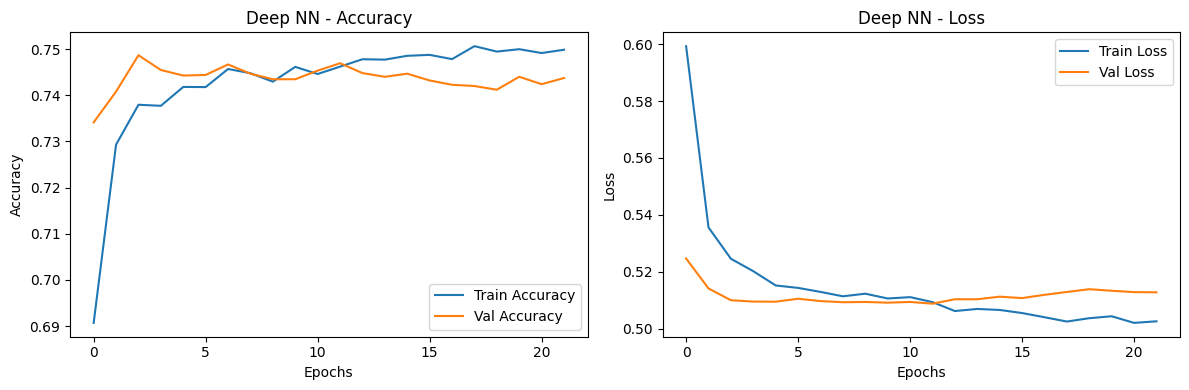

In [360]:
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_deep_mm.history['accuracy'], label='Train Accuracy')
plt.plot(history_deep_mm.history['val_accuracy'], label='Val Accuracy')
plt.title('Deep NN - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_deep_mm.history['loss'], label='Train Loss')
plt.plot(history_deep_mm.history['val_loss'], label='Val Loss')
plt.title('Deep NN - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [361]:
import joblib
joblib.dump(logistic_model_mm, "model.pkl")   # must be the one fit on x_train_mm
joblib.dump(minmax_scaler, "scaler.pkl")

['scaler.pkl']